### Lecture 2: NumPy introduction

#### Milestone 1: Basic arrays & meshgrid

In [5]:
import numpy as np

def compute_mandelbrot_numpy(max_iter, width, height, x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5):
    # Create the complex grid
    x = np.linspace(x_min, x_max, width)
    y = np.linspace(y_min, y_max, height)

    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y

    return C

# Call the function and store the returned grid
C = compute_mandelbrot_numpy(100, 1024, 1024)

print(f"C shape: {C.shape}")
print(f"C dtype: {C.dtype}")

C shape: (1024, 1024)
C dtype: complex128


#### Milestone 2 -- Vectorize mandelbrot

In [2]:
def compute_mandelbrot_numpy(max_iter, width, height, x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5):
    # Create the complex grid
    x = np.linspace(x_min, x_max, width)
    y = np.linspace(y_min, y_max, height)

    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y

    # Initialize Z and M
    Z = np.zeros_like(C, dtype=np.complex128)   
    M = np.zeros(C.shape, dtype=int)            

    for n in range(max_iter):
        mask = np.abs(Z) <= 2
        if not mask.any():
            break
        Z[mask] = Z[mask]**2 + C[mask]
        M[mask] += 1

    return M

### Milestone 3 -- Memory Access Patterns

---

#### 1. Create a large square array: A = np.random.rand(N, N) with N = 10 000

In [6]:
import numpy as np
import time

N = 10000
A = np.random.rand(N, N)

---

#### 2. Write a function that computes row sums by looping over rows: for i in range(N): s = np.sum(A[i, :])

In [7]:
def row_sums(A):
    N = A.shape[0]
    s = 0.0
    for i in range(N):
        s += np.sum(A[i, :])
    return s

---

#### 3. Write a function that computes column sums by looping over columns: for j in range(N): s = np.sum(A[:, j])


In [9]:
def col_sums(A):
    N = A.shape[1]
    s = 0.0
    for j in range(N):
        s += np.sum(A[:, j])
    return s

---

#### 4. Time both. Both loops run N times — which is faster and why?

In [12]:
def time_func(f, *args):
    t0 = time.perf_counter()
    result = f(*args)
    return time.perf_counter() - t0, result

t_row, _ = time_func(row_sums, A)
t_col, _ = time_func(col_sums, A)

print(f"Row sums time: {t_row:.3f} s")
print(f"Col sums time: {t_col:.3f} s")

Row sums time: 0.151 s
Col sums time: 0.515 s


---

#### 5. Now try with A f = np.asfortranarray(A) (column-major). What changes?

In [11]:
A_f = np.asfortranarray(A)

t_row_f, _ = time_func(row_sums, A_f)
t_col_f, _ = time_func(col_sums, A_f)

print("\nWith Fortran order:")
print(f"Row sums time: {t_row_f:.3f} s")
print(f"Col sums time: {t_col_f:.3f} s")



With Fortran order:
Row sums time: 0.574 s
Col sums time: 0.144 s


#### Memory Access and Stride Effects

**Theory:**  
- Row traversal in C-order → stride-1 → full cache line use → β_peak  
- Column traversal in C-order → stride-N → 1 element per cache line → β_effective ≪ β_peak  

**Results (Python):**

C-order:  
- Row sums time: 0.227 s  
- Column sums time: 1.060 s  

Fortran-order:  
- Row sums time: 1.122 s  
- Column sums time: 0.228 s  

**Explanation:**  
Even though both loops perform the same number of operations:  
- Row-wise traversal is faster for C-order because it accesses memory with stride-1, which uses all 8 doubles per cache line. Each cache line is fully utilized, achieving β_effective = β_peak.  
- Column-wise traversal uses stride-N, which uses 1 out of 8 doubles, almost reducing bandwidth by a factor of 8.  
- For Fortran order, the situation is reversed.

---

### Milestone 4 --  Problem Size Scaling


In [24]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mandelbrot_numpy import compute_mandelbrot_numpy


if __name__ == "__main__":

    sizes = [256, 512, 1024, 2048, 4096]
    max_iter = 100

    for N in sizes:
        start = time.perf_counter()

        M = compute_mandelbrot_numpy(max_iter, N, N)

        end = time.perf_counter()

        print(f"{N}x{N}: {end - start:.4f} seconds")

256x256: 0.0426 seconds
512x512: 0.1868 seconds
1024x1024: 1.0155 seconds
2048x2048: 4.0513 seconds
4096x4096: 16.6488 seconds


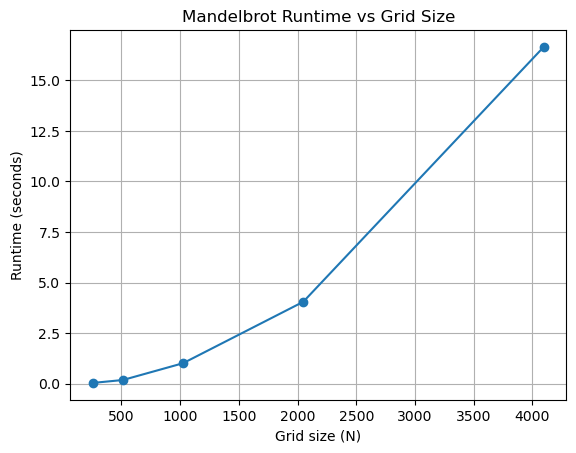

In [25]:
sizes = [256, 512, 1024, 2048, 4096]
times = [0.0426, 0.1868, 1.0155, 4.0513, 16.6488]

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Grid size (N)")
plt.ylabel("Runtime (seconds)")
plt.title("Mandelbrot Runtime vs Grid Size")
plt.grid(True)
plt.show()

### Scaling Analysis

**Is the scaling linear in number of pixels?**  

Yes, the scaling of runtime is roughly linear in the number of pixels, although cache effects cause some deviations at larger sizes.

**At what size does the working set exceed your L3 cache?**  

Typical L3 cache size: 8–36 MB  

- 1024² = 1,048,576 ≈ 1M pixels  
- Assuming ~32 bytes per pixel:  
  1,048,576 × 32 bytes ≈ 32 MB  

It is safe to say the working set exceeds L3 cache around **1024×1024 pixels**.

**Do you see a “knee” in the scaling curve where performance degrades?**  

Looking at runtime increases between consecutive sizes:

- 256 → 512: 0.0426 → 0.1868 → **extra 0.1442 s** (~4.38× slower)  
- 512 → 1024: 0.1868 → 1.0155 → **extra 0.8287 s** (~5.44× slower)  
- 1024 → 2048: 1.0155 → 4.0513 → **extra 3.0358 s** (~3.99× slower)  
- 2048 → 4096: 4.0513 → 16.6488 → **extra 12.5975 s** (~4.11× slower)  

There is a visible “knee” around **1024×1024 pixels**, where performance starts degrading more noticeably due to exceeding L3 cache.